```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 工作搜寻 V：风险敏感型偏好

```{include} _admonition/gpu.md
```

```{contents} Contents
:depth: 2
```


## 概述

风险敏感型偏好是各类动态规划问题中常见的一种扩展设定。

本讲座通过工作搜寻问题介绍风险敏感型递归偏好。

下面给出了一些动机说明。

## 大纲

在现实世界与工作相关的决策中，个人和家庭都会关心风险。

例如，有些人可能宁愿接受手头一份中等的录用邀约，也不愿冒险等待下一期可能出现的更高录用邀约，即使不对未来收益进行贴现也是如此。

（即所谓“双鸟在林不如一鸟在手”。）

在本系列前面的工作搜寻讲座中，我们通过添加一个凹形流量效用函数 $u$ 引入了一定程度的风险厌恶。

不幸的是，这种做法并不能将我们所描述的这种风险偏好单独分离出来。

这是因为添加凹形效用函数还会以其他方式改变主体的偏好，比如改变其对消费平滑的偏好程度。

因此，如果我们想研究纯粹的风险效应，就需要一种不同的解决办法。

一种可能的方案是引入风险敏感型偏好。

下面我们将展示如何做到这一点，并研究其对主体选择的影响。

我们将使用 JAX 和 QuantEcon 库：

In [1]:
!pip install quantecon

我们使用以下代码导入库。

In [2]:
import jax
import jax.numpy as jnp
from jax import lax
import quantecon as qe
from typing import NamedTuple
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 风险敏感性简介

让我们从一个静态环境开始讨论。

如果 $Y$ 是一个随机收益，而主体对该收益的评价为 $e := \mathbb{E} Y$，
那么我们称该主体是**风险中性的**。

有时我们希望将主体建模为风险厌恶型。

一种做法是将他们对收益 $Y$ 的评价改为

$$
e_{\theta} = \frac{1}{\theta} \ln\left( \mathbb{E} [ \exp(\theta Y) ] \right)
$$

其中 $\theta$ 是满足 $\theta < 0$ 的一个数。

值 $e_{\theta}$ 有时被称为 $Y$ 的**熵风险调整期望**。

### 一个高斯分布的例子

理解该影响的一种方式是假设 $Y$ 服从正态分布
$N(\mu, \sigma^2)$，即其均值为 $\mu$，方差为 $\sigma^2$。

对于这样的 $Y$，我们的目标是计算风险调整期望。

如果我们意识到 $\mathbb{E}[\exp(\theta Y)]$
正是正态分布的[矩生成函数](https://en.wikipedia.org/wiki/Moment-generating_function)（MGF），这个计算就会变得直截了当。

利用正态分布的矩生成函数的著名表达式，我们得到

$$
\mathbb{E}[\exp(\theta Y)] = \exp\left(\theta\mu + \frac{\theta^2\sigma^2}{2}\right)
$$

因此，

$$
e_\theta 
= \frac{1}{\theta} \ln\left( \exp\left(\theta\mu + \frac{\theta^2\sigma^2}{2}\right) \right) 
= \frac{1}{\theta} \left(\theta\mu + \frac{\theta^2\sigma^2}{2}\right)
$$

化简可得

$$
e_\theta = \mu + \frac{\theta\sigma^2}{2}
$$

我们立即可以看出，主体偏好更高的平均收益 $\mu$。

同时，由于 $\theta < 0$，风险调整期望随着 $\sigma$ 的增加而下降。

具体而言，$e_\theta$ 随着风险的增加而减少。

下面通过等高线图可视化 $e_\theta$ 作为 $\mu$ 和 $\sigma$ 的函数，其中 $\theta=-1$。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


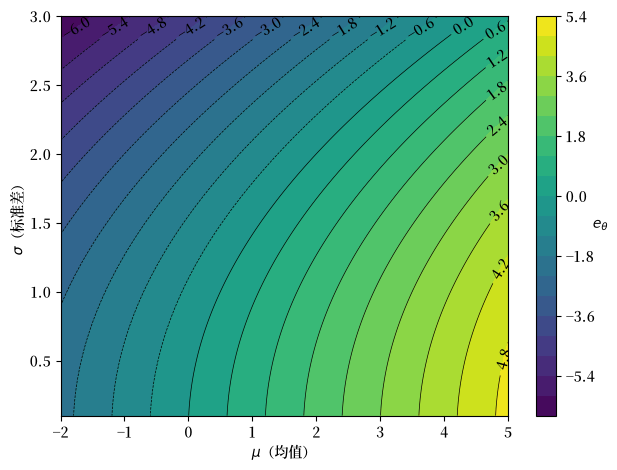

In [3]:
θ = -1

μ_vals = np.linspace(-2, 5, 200)
σ_vals = np.linspace(0.1, 3, 200)
μ_grid, σ_grid = np.meshgrid(μ_vals, σ_vals)

e_θ = μ_grid + (θ * σ_grid**2) / 2

# 创建等高线图
fig, ax = plt.subplots()
contour = ax.contour(
    μ_grid, σ_grid, e_θ, levels=20, colors='black', linewidths=0.5
)
contourf = ax.contourf(
    μ_grid, σ_grid, e_θ, levels=20, cmap='viridis'
)
ax.clabel(contour, inline=True)
cbar = plt.colorbar(contourf, ax=ax)
cbar.set_label(r'$e_\theta$', rotation=0)

ax.set_xlabel(r'$\mu$（均值）')
ax.set_ylabel(r'$\sigma$（标准差）')
plt.tight_layout()
plt.show()

同样，我们看到主体偏好更高的平均收益，但厌恶风险。

### 一个更一般的情形

前面的分析依赖于高斯（正态）假设以获得解析解。

我们可以通过模拟来研究所有其他情形。

例如，假设 $Y$ 服从贝塔分布 Beta$(a, b)$。

这里我们设定 $a=b=2.0$，并使用蒙特卡洛方法计算 $e_{\theta}$。

该方法为：

1. 从 Beta$(2,2)$ 中抽取样本 $Y_1, \ldots, Y_n$
2. 用对 $\exp(\theta Y_i)$ 的平均值替代 $\mathbb{E}$

我们对 $\theta$ 在 $-2$ 到 $-0.1$ 之间的 100 个网格点上执行此操作。

下面是 $e_{\theta}$ 相对于 $\theta$ 的图像。

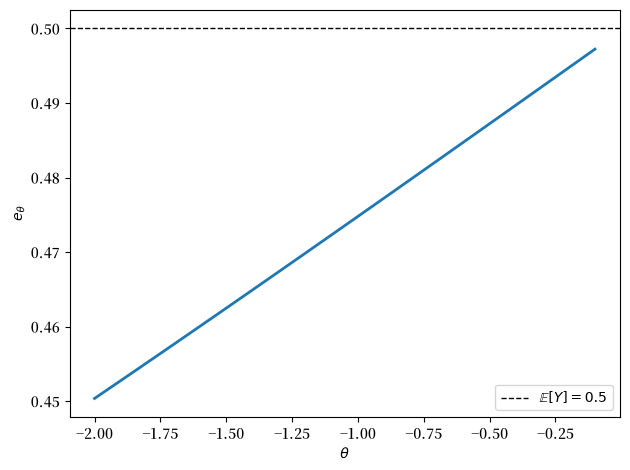

In [4]:
# 设定参数
a, b = 2.0, 2.0
mc_size = 1_000_000  # 大量蒙特卡洛样本
θ_grid = jnp.linspace(-2, -0.1, 100)

# 使用 JAX 从 Beta(2, 2) 分布中抽取样本
key = jax.random.key(1234)
Y_samples = jax.random.beta(key, a, b, shape=(mc_size,))

# 定义计算单个 θ 值对应的 e_θ 的函数
def compute_e_θ(θ):
    """计算 e_θ = (1/θ) * ln(E[exp(θ * Y)])"""
    expectation = jnp.mean(jnp.exp(θ * Y_samples))
    return (1 / θ) * jnp.log(expectation)

# 使用 vmap 对 θ_grid 进行向量化
compute_e_θ_vec = jax.vmap(compute_e_θ)
e_θ_values = compute_e_θ_vec(θ_grid)

# 绘制结果
fig, ax = plt.subplots()
ax.plot(θ_grid, e_θ_values, lw=2)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$e_\theta$')
ax.axhline(y=0.5, color='black', linestyle='--',
           linewidth=1, label=r'$\mathbb{E}[Y] = 0.5$')
ax.legend()
plt.tight_layout()
plt.show()

该图展示了风险调整评估值 $e_\theta$ 如何随风险厌恶参数 $\theta$ 变化。

当 $\theta \to 0$ 时，$e_\theta$ 的值趋近于 $Y$ 的期望值，
  即对于 Beta(2,2) 而言 $\mathbb{E}[Y] = \frac{a}{a+b} = \frac{2}{4} = 0.5$。

这是合理的，因为当 $\theta \to 0$ 时，主体变为风险中性。

随着 $\theta$ 变得更负，$e_\theta$ 会下降。

这反映出一个更加风险厌恶的主体，对不确定收益 $Y$ 的估值低于其期望值。

### 均值保持展开

下一个练习要求你研究均值保持展开（mean-preserving spread）对风险调整期望的影响。

```{exercise}
:label: mcr_ex0

保持 $Y \sim \text{Beta}(2, 2)$ 不变，并固定 $\theta = -2$。

再次使用蒙特卡洛方法计算

$$
e_{\theta} = \frac{1}{\theta} \ln\left( \mathbb{E} [ \exp(\theta X) ] \right)
$$

其中 $X = Y + \sigma Z$，$Z$ 是标准正态随机变量。

$e_\theta$ 如何随 $\sigma$ 变化？

你能否给出一些直觉解释这一现象（考虑到主体是风险厌恶的）？

请用图示说明你的结果。
```

```{solution-start} mcr_ex0
:class: dropdown
```

以下是我们的解答。

findfont: Failed to find font weight normal, now using 600.


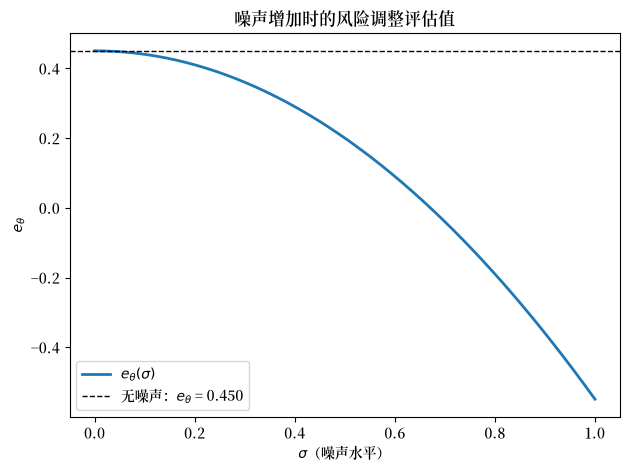

In [5]:
a, b = 2.0, 2.0
θ = -2.0
mc_size = 1_000_000  # 大量蒙特卡洛样本
σ_grid = jnp.linspace(0.0, 1.0, 50)

# 设定随机种子以保证可复现性
key = jax.random.key(1234)
key_y, key_z = jax.random.split(key)

# 从 Beta(2, 2) 分布中抽取样本
Y_samples = jax.random.beta(key_y, a, b, shape=(mc_size,))

# 抽取标准正态样本（对所有 σ 值复用）
Z_samples = jax.random.normal(key_z, shape=(mc_size,))

# 定义计算单个 σ 值对应的 e_θ 的函数
def compute_e_θ(σ):
    """计算 X = Y + σ * Z 时的 e_θ"""
    # 计算 X = Y + σ * Z
    X_samples = Y_samples + σ * Z_samples

    # 使用蒙特卡洛方法计算 E[exp(θ * X)]
    expectation = jnp.mean(jnp.exp(θ * X_samples))

    # 计算 e_θ
    return (1 / θ) * jnp.log(expectation)

# 使用 vmap 对 σ_grid 进行向量化
compute_e_θ_vec = jax.vmap(compute_e_θ)
e_θ_values = compute_e_θ_vec(σ_grid)

# 绘制结果
fig, ax = plt.subplots()
ax.plot(σ_grid, e_θ_values, lw=2, label=r'$e_\theta(\sigma)$')
ax.set_xlabel(r'$\sigma$（噪声水平）')
ax.set_ylabel(r'$e_\theta$')
ax.set_title(r'噪声增加时的风险调整评估值')
ax.axhline(y=e_θ_values[0], color='black', linestyle='--', linewidth=1,
           label=f'无噪声：$e_\\theta$ = {e_θ_values[0]:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

该图清楚地显示，$e_\theta$ 随着 $\sigma$ 的增加而单调下降。

由于该主体是风险厌恶的（$\theta = -2 < 0$），她厌恶不确定性。

随着我们增大 $\sigma$，波动性会增加，因为

$$
\text{Var}(X) = \text{Var}(Y) + \sigma^2 \text{Var}(Z) = \text{Var}(Y) + \sigma^2
$$

与此同时，期望值保持不变，因为

$$
\mathbb{E}[X] = \mathbb{E}[Y + \sigma Z] = \mathbb{E}[Y] + \sigma \mathbb{E}[Z] = \mathbb{E}[Y] = 0.5
$$

因此平均收益并不随 $\sigma$ 变化。

换句话说，这位风险厌恶的主体并没有因承担额外风险而获得补偿。

这就是为什么该随机收益的估值会下降。

```{solution-end}
```

## 回到工作搜寻问题

在讲座 {doc}`mccall_fitted_vfi` 中，我们研究了一个带有分离、马尔可夫工资抽取和拟合价值函数迭代的工作搜寻模型。

工资邀约过程是连续的，并满足

$$
    W_t = \exp(X_t)
    \quad \text{其中} \quad
    X_{t+1} = \rho X_t + \nu Z_{t+1}
$$

且 $\{Z_t\}$ 独立同分布，服从标准正态分布。

现在让我们研究同一个模型，但将风险中性期望的假设替换为风险厌恶期望。

具体而言，那篇讲座中的条件期望

$$
    (P v_u)(w) = \mathbb{E} v_u( w^\rho  \exp(\nu Z) )
$$

被替换为

$$
(P_\theta v_u)(w)
= \frac{1}{\theta} \ln
    \left[
        \mathbb{E} \exp(\theta v_u( w^\rho  \exp(\nu Z) ))
    \right]
$$

除此之外，模型的其余部分保持不变。

我们现在求解这一动态规划问题，并研究 $\theta$ 对保留工资的影响。

### 设置

下面是用于存储参数及默认参数值的类。

In [6]:
class Model(NamedTuple):
    c: float              # 失业补偿
    α: float              # 工作分离率
    β: float              # 贴现因子
    ρ: float              # 工资持续性
    ν: float              # 工资波动率
    θ: float              # 风险厌恶参数
    w_grid: jnp.ndarray   # 用于拟合价值函数迭代的网格点
    z_draws: jnp.ndarray  # 来自标准正态分布的抽样

def create_mccall_model(
        c: float = 1.0,
        α: float = 0.1,
        β: float = 0.96,
        ρ: float = 0.9,
        ν: float = 0.2,
        θ: float = -1.5,
        grid_size: int = 100,
        mc_size: int = 1000,
        seed: int = 1234
    ):
    """用于创建 McCall 模型实例的工厂函数。"""

    key = jax.random.key(seed)
    z_draws = jax.random.normal(key, (mc_size,))

    # 离散化只是为了获得适合插值的工资网格
    mc = qe.markov.tauchen(grid_size, ρ, ν)
    w_grid = jnp.exp(jnp.array(mc.state_values))

    return Model(c, α, β, ρ, ν, θ, w_grid, z_draws)

### 贝尔曼方程

我们的构造是对 {doc}`mccall_fitted_vfi` 中贝尔曼方程的直接扩展。

首先，我们利用已就业工人的贝尔曼方程，用 $(P_\theta v_u)(w)$ 表示
$v_e(w)$：

$$
v_e(w) = 
\frac{1}{1-\beta(1-\alpha)} \cdot (u(w) + \alpha\beta(P_\theta v_u)(w))
$$

将其代入失业主体的贝尔曼方程，得到：

$$
v_u(w) = 
\max
\left\{
    \frac{1}{1-\beta(1-\alpha)} \cdot (u(w) + \alpha\beta(P_\theta v_u)(w)),
    u(c) + \beta(P_\theta v_u)(w)
\right\}
$$

我们使用价值函数迭代来求解 $v_u$。

然后计算最优策略：若 $v_e(w) ≥ u(c) + β(P_\theta v_u)(w)$，则接受该工资。

下面是用于更新 $v_u$ 的贝尔曼算子。

In [7]:
def T(model, v):
    # 拆解模型参数
    c, α, β, ρ, ν, θ, w_grid, z_draws = model

    # 对以数组表示的价值函数进行插值
    vf = lambda x: jnp.interp(x, w_grid, v)

    def compute_expectation(w):
        # 使用蒙特卡洛方法计算积分 (P_θ v)(w)
        inner = jnp.mean(jnp.exp(θ * vf(w**ρ * jnp.exp(ν * z_draws))))
        return (1 / θ) * jnp.log(inner)

    compute_exp_all = jax.vmap(compute_expectation)
    P_θ_v = compute_exp_all(w_grid)

    d = 1 / (1 - β * (1 - α))
    accept = d * (w_grid + α * β * P_θ_v)
    reject = c + β * P_θ_v
    return jnp.maximum(accept, reject)

下面是求解器：

In [8]:
@jax.jit
def vfi(
        model: Model,
        tolerance: float = 1e-6,   # 误差容限
        max_iter: int = 100_000,   # 最大迭代次数上限
    ):

    v_init = jnp.zeros(model.w_grid.shape)

    def cond(loop_state):
        v, error, i = loop_state
        return (error > tolerance) & (i <= max_iter)

    def update(loop_state):
        v, error, i = loop_state
        v_new = T(model, v)
        error = jnp.max(jnp.abs(v_new - v))
        new_loop_state = v_new, error, i + 1
        return new_loop_state

    initial_state = (v_init, tolerance + 1, 1)
    final_loop_state = lax.while_loop(cond, update, initial_state)
    v_final, error, i = final_loop_state

    return v_final

下一个函数在假设 $v$ 为价值函数的前提下计算最优策略：

In [9]:
def get_greedy(v: jnp.ndarray, model: Model) -> jnp.ndarray:
    """获取 v-贪婪策略。"""
    c, α, β, ρ, ν, θ, w_grid, z_draws = model

    # 对以数组表示的价值函数进行插值
    vf = lambda x: jnp.interp(x, w_grid, v)

    def compute_expectation(w):
        # 使用蒙特卡洛方法计算积分 (P_θ v)(w)
        inner = jnp.mean(jnp.exp(θ * vf(w**ρ * jnp.exp(ν * z_draws))))
        return (1 / θ) * jnp.log(inner)

    compute_exp_all = jax.vmap(compute_expectation)
    P_θ_v = compute_exp_all(w_grid)

    d = 1 / (1 - β * (1 - α))
    accept = d * (w_grid + α * β * P_θ_v)
    reject = c + β * P_θ_v
    σ = accept >= reject
    return σ

下面是一个函数，它接收一个 `Model` 实例
并返回对应的保留工资。

In [10]:
@jax.jit
def get_reservation_wage(σ: jnp.ndarray, model: Model) -> float:
    """
    根据给定的策略计算保留工资。

    参数：
    - σ：策略数组，σ[i] = True 表示接受工资 w_grid[i]
    - model：包含工资数值的模型实例

    返回：
    - 保留工资（策略指示接受的最低工资）
    """
    c, α, β, ρ, ν, θ, w_grid, z_draws = model

    # 找到策略指示接受的第一个索引
    # σ 是一个布尔数组，argmax 返回第一个 True 值的位置
    first_accept_idx = jnp.argmax(σ)

    # 如果没有接受（全部为 False），返回无穷大
    # 否则返回第一个接受索引处的工资
    return jnp.where(jnp.any(σ), w_grid[first_accept_idx], jnp.inf)

让我们在默认参数下求解该模型：

In [11]:
# 首先，让我们求解默认的 θ = -1.5
model = create_mccall_model()
c, α, β, ρ, ν, θ, w_grid, z_draws = model

print(f"求解 θ = {θ} 时的模型")
v_star = vfi(model)
σ_star = get_greedy(v_star, model)
w_bar = get_reservation_wage(σ_star, model)
print(f"默认参数下的保留工资：{w_bar:.4f}")

求解 θ = -1.5 时的模型
默认参数下的保留工资：1.0720


默认参数下的保留工资：1.0720


### 保留工资如何随 $\theta$ 变化？

现在让我们考察保留工资随着风险厌恶参数变化时的走势。

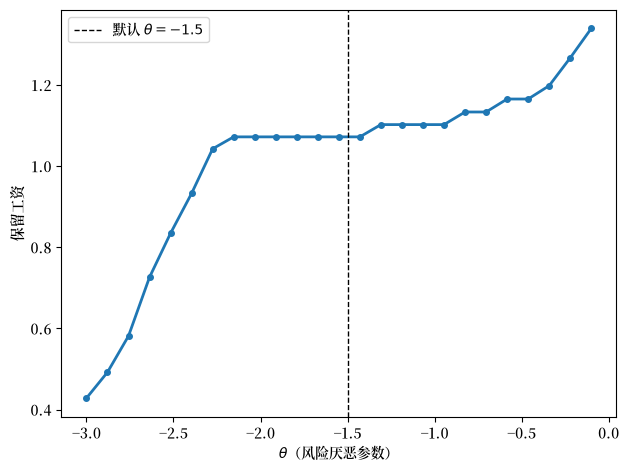

In [12]:
# 创建 θ 值的网格（全部为负值，代表风险厌恶）
θ_grid = jnp.linspace(-3.0, -0.1, 25)

# 定义计算单个 θ 值对应保留工资的函数
def compute_res_wage_for_theta(θ):
    """计算给定 θ 值下的保留工资"""
    model = create_mccall_model(θ=θ)
    v = vfi(model)
    σ = get_greedy(v, model)
    w_bar = get_reservation_wage(σ, model)
    return w_bar

# 使用 vmap 对 θ_grid 进行向量化
compute_res_wages_vec = jax.vmap(compute_res_wage_for_theta)
reservation_wages = compute_res_wages_vec(θ_grid)

# 绘制结果
fig, ax = plt.subplots()
ax.plot(θ_grid, reservation_wages,
        lw=2, marker='o', markersize=4)
ax.set_xlabel(r'$\theta$（风险厌恶参数）')
ax.set_ylabel('保留工资')
ax.axvline(x=-1.5, color='black', ls='--',
           linewidth=1, label=r'默认 $\theta = -1.5$')
ax.legend()
plt.tight_layout()
plt.show()

随着 $\theta$ 变得不那么负（趋向于零），保留工资会增加。

等价地说，随着主体变得更加风险厌恶（$\theta$ 更负），保留工资会下降。

原因在于，一个更加风险厌恶的主体会更加看重就业带来的确定性收入，
  相对而言更不重视继续搜寻所带来的不确定的未来前景。

因此，他们愿意接受更低的工资以摆脱失业状态。

```{exercise}
:label: mcr_ex1

利用模拟来研究长期失业率如何随 $\theta$ 变化。

使用上一节中的参数，也就是我们研究保留工资如何随 $\theta$ 变化时所用的参数。

你可以使用 {doc}`mccall_fitted_vfi` 中的模拟代码，并进行适当修改。
```

```{solution-start} mcr_ex1
:class: dropdown
```

为了计算长期失业率，我们首先编写一个用于更新单个主体状态的函数。

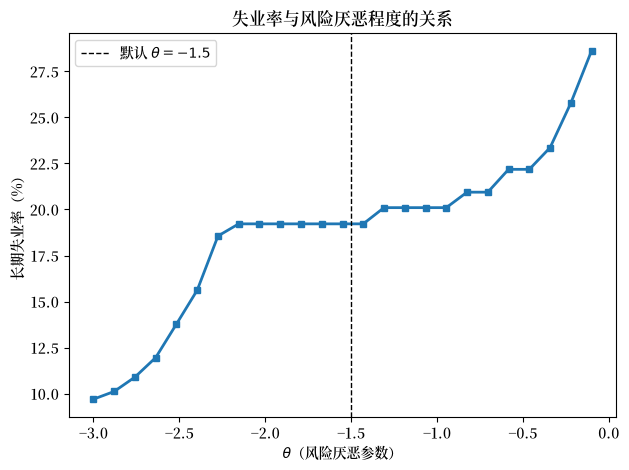

In [13]:
@jax.jit
def simulate_single_agent(key, model, w_star, num_periods=200):
    """
    对单个主体模拟 num_periods 期。
    返回最终就业状态（1 表示就业，0 表示失业）。
    """
    c, α, β, ρ, ν, θ, w_grid, z_draws = model

    # 从任意初始条件开始
    w = 1.0
    status = 1

    def update(t, loop_state):
        w, status, key = loop_state
        key, k1, k2 = jax.random.split(key, 3)

        # 更新工资
        z = jax.random.normal(k2)
        w_new = w**ρ * jnp.exp(ν * z)

        # 就业状态转移
        sep_draw = jax.random.uniform(k1)
        becomes_unemployed = sep_draw < α

        # 检查失业工人是否接受工资
        accepts_job = w >= w_star

        # 更新就业状态
        new_status = jnp.where(
            status,
            1 - becomes_unemployed,   # 就业路径
            accepts_job               # 失业路径
        )

        new_wage = jnp.where(
            status,
            jnp.where(becomes_unemployed, w_new, w),  # 就业路径
            jnp.where(accepts_job, w, w_new)          # 失业路径
        )

        return (new_wage, new_status, key)

    init_state = (w, status, key)
    final_state = lax.fori_loop(0, num_periods, update, init_state)
    _, final_status, _ = final_state
    return final_status


def compute_unemployment_rate(model, w_star, num_agents=1000, num_periods=200, seed=12345):
    """
    通过横截面模拟计算失业率。

    这里不是对单个主体模拟很长的时间序列，而是并行模拟
    大量主体，各自模拟较短的时间段。在 JAX 并行化下，这样效率更高。

    稳态满足：
    - 就业工人以速率 α 失去工作
    - 失业工人以速率 (1 - F(w*)) 找到可以接受的工作

    我们对 num_agents 个主体各模拟 num_periods 期，然后计算
    最终失业者所占的比例。
    """
    # 为每个主体创建各自的随机数密钥
    key = jax.random.key(seed)
    keys = jax.random.split(key, num_agents)

    # 在主体维度上向量化模拟（并行化！）
    simulate_agents = jax.vmap(
        lambda k: simulate_single_agent(k, model, w_star, num_periods)
    )

    # 并行运行所有主体的模拟
    status_cross_section = simulate_agents(keys)

    # 由于 status=1 表示就业，失业率等于 1 - mean(status)
    unemployment_rate = 1 - jnp.mean(status_cross_section)

    return unemployment_rate


# 定义计算单个 θ 值对应失业率的函数
def compute_u_rate_for_theta(θ):
    """计算给定 θ 值下的失业率"""
    model = create_mccall_model(θ=θ)
    v = vfi(model)
    σ = get_greedy(v, model)
    w_star = get_reservation_wage(σ, model)
    u_rate = compute_unemployment_rate(
        model, w_star, num_agents=5000, num_periods=200
    )
    return u_rate

# 使用 vmap 对 θ_grid 进行向量化
compute_u_rates_vec = jax.vmap(compute_u_rate_for_theta)
unemployment_rates = compute_u_rates_vec(θ_grid)

# 绘制结果
fig, ax = plt.subplots()
ax.plot(θ_grid, unemployment_rates * 100,
        lw=2, marker='s', markersize=4)
ax.set_xlabel(r'$\theta$（风险厌恶参数）')
ax.set_ylabel('长期失业率（%）')
ax.set_title('失业率与风险厌恶程度的关系')
ax.axvline(x=-1.5, color='black', ls='--', linewidth=1, label=r'默认 $\theta = -1.5$')
ax.legend()
plt.tight_layout()
plt.show()

我们看到，随着主体变得更加风险厌恶（$\theta$ 更负），失业率会下降。

这是因为风险厌恶程度更高的工人保留工资更低，
因此他们会接受范围更广的工作邀约。

结果就是，他们花在寻找更好机会上的失业时间更短。

```{solution-end}
```